In [1]:
suppressPackageStartupMessages({require(data.table)
require(ggplot2)
require(ggpubr)})

subject_color_map = c(
  "FH1001" = "#1f77b4", "FH1002" = "#ff7f0e", "FH1003" = "#279e68",
  "FH1004" = "#d62728", "FH1005" = "#aa40fc", "FH1006" = "#8c564b",
  "FH1007" = "#e377c2", "FH1008" = "#b5bd61", "FH1009" = "#17becf",
  "FH1010" = "#aec7e8", "FH1011" = "#ffbb78", "FH1012" = "#98df8a",
  "FH1014" = "#ff9896", "FH1016" = "#c5b0d5", "FH1017" = "#c49c94",
  "FH1018" = "#f7b6d2", "FH1021" = "#dbdb8d"
)

In [2]:
tmp = fread('../../data/figure-inputs/msd/processed_covid_data.csv')

In [3]:
textSize = 20
# Define Recall Response
recall_response <- tmp[variable=='XBB15V2_Mean' & value > 1000 &  Visit =='End-Ind']
visit_levels <- c("EI", "ASCT60D", "ASCT1y", "ASCT2y")
tmp[, Visit := factor(fcase(Visit == "End-Ind", "EI", default = Visit), levels = visit_levels)]

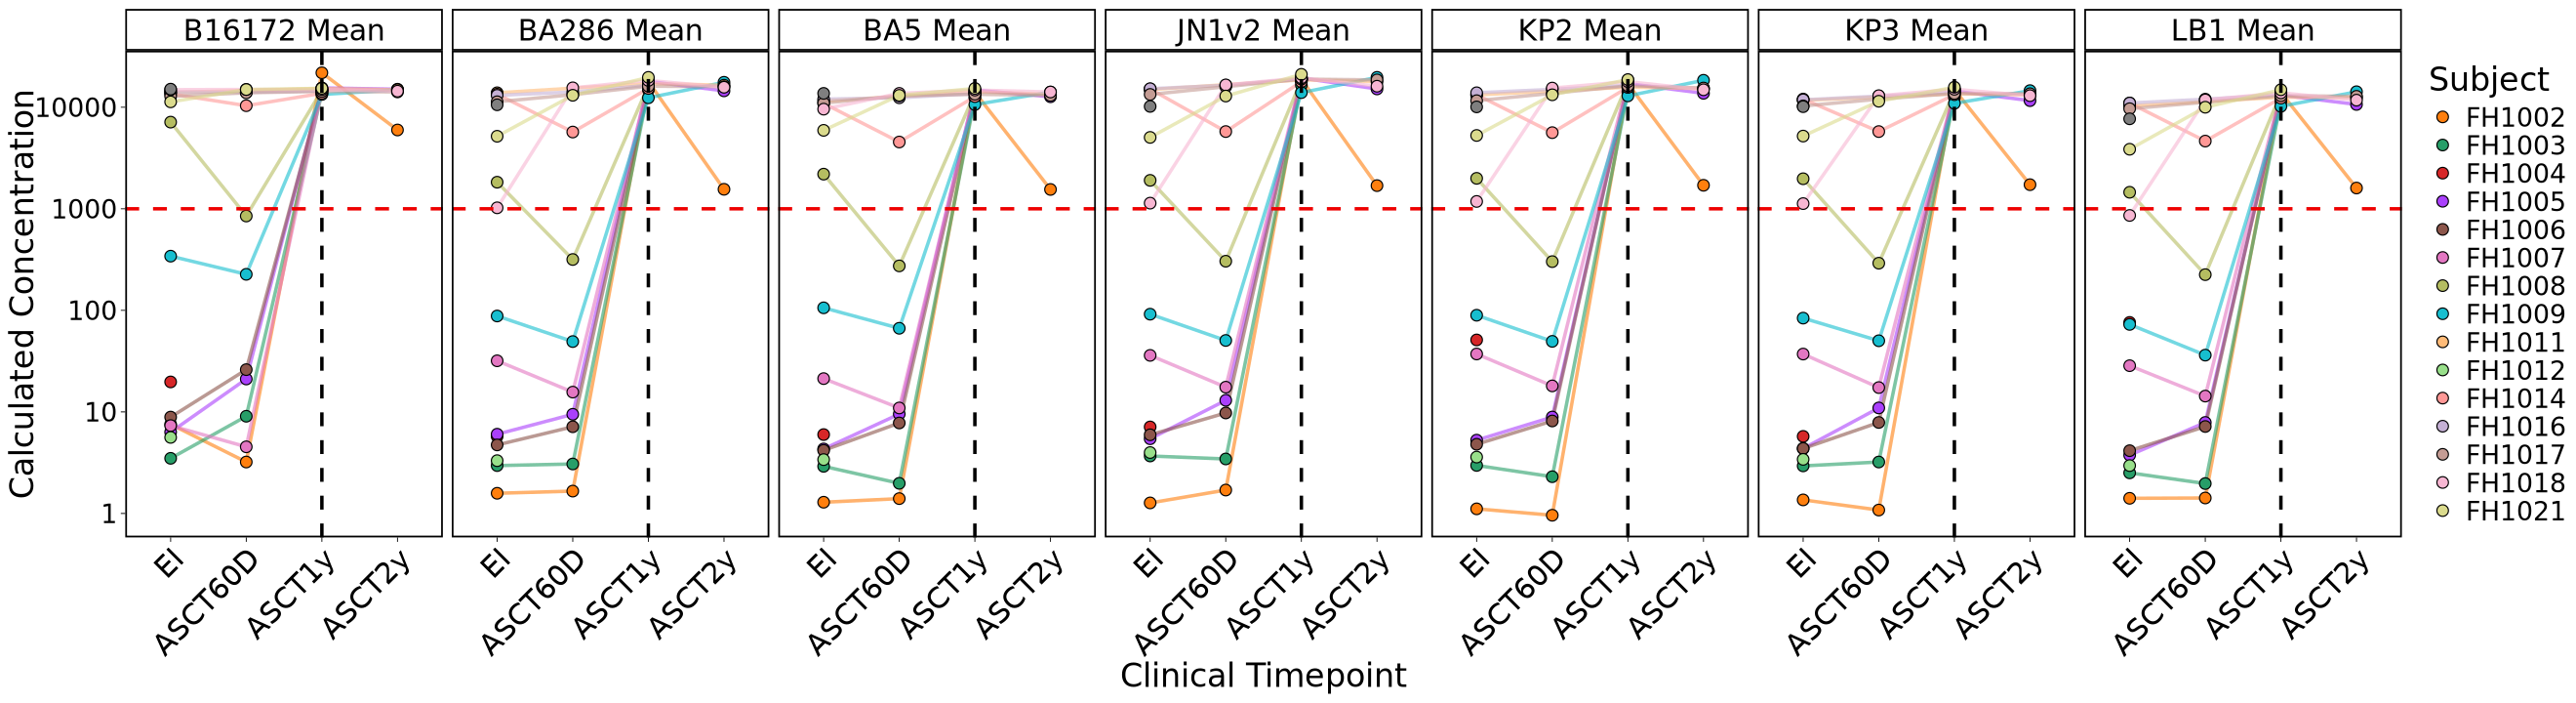

In [4]:
options(repr.plot.width = 22, repr.plot.height = 6)
p <- ggplot(
  tmp[!variable %in% c("NC_Mean", "Spike_Mean", "XBB15V2_Mean")],
  aes(
    x = Visit,
    y = value,
    group = Subject,
    color = Subject,
  )
) +  
  geom_line(alpha = 0.6, linewidth = 1, show.legend = FALSE) +
  geom_point(size = 3, shape = 21, aes(fill = Subject), color = "black") +
  geom_vline(xintercept = "ASCT1y", lty = 2, lwd = 1) +
  facet_wrap(~variable, nrow = 1, labeller = labeller(variable = function(x) gsub("_", " ", x))) +
  scale_y_log10() +
  theme_linedraw() +
  scale_color_manual(values = subject_color_map) +                                                                                
  scale_fill_manual(values = subject_color_map) + 
  theme(
    text = element_text(size = 20),
    plot.title = element_text(face = "bold"),
    strip.text.x = element_text(size = 18, color = "black"),
    strip.background = element_rect(fill = "white", linewidth = 1),
    axis.text.x = element_text(size = 18, angle = 45, hjust = 1),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1)
  ) +
  geom_hline(yintercept = 1000, lty = 2, lwd = 1, col = "red2") +
  xlab("Clinical Timepoint") +
  ylab("Calculated Concentration")
p

ggsave("../../data/figure-outputs/supplementary-7/sup_7b.pdf", plot = p, width = 22, height = 6, dpi = 200, device = cairo_pdf)